# HydroSims Suppression Tutorial

This notebook shows how to load and plot the matter power spectrum suppression
$$\mathcal{S}(k, z) = P_{\rm bary}(k,z) \,/\, P_{\rm dmo}(k,z)$$
from the bundled hydrodynamical simulations, and overlays a **BCemu2025** fiducial prediction.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import BCemu
from BCemu.datasets import HydroSimDataSk, HydroSimDataPk

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 9,
})

## 2. Available Simulations

In [2]:
print("HydroSimDataSk — suppression S(k,z):")
for name in HydroSimDataSk.available():
    print("  ", name)

print()
print("HydroSimDataPk — raw P(k,z):")
for name in HydroSimDataPk.available():
    print("  ", name)

HydroSimDataSk — suppression S(k,z):
   HorizonAGN
   TNG300
   EAGLE
   HorizonAGN_HzAGN
   Illustris
   MB2
   TNG100
   BAHAMAS_AGN7.6
   BAHAMAS_AGN7.8
   BAHAMAS_AGN8.0
   FLAMINGO_Jet
   FLAMINGO_Jet_fgas-4sigma
   FLAMINGO_L1_m8
   FLAMINGO_L1_m9
   FLAMINGO_fgas+2sigma
   FLAMINGO_fgas-2sigma
   FLAMINGO_fgas-4sigma
   FLAMINGO_fgas-8sigma

HydroSimDataPk — raw P(k,z):
   BAHAMAS_AGN7.6_DMONLY
   BAHAMAS_AGN7.6_matter
   BAHAMAS_AGN7.8_DMONLY
   BAHAMAS_AGN7.8_matter
   BAHAMAS_AGN8.0_DMONLY
   BAHAMAS_AGN8.0_matter
   BAHAMAS_Theat7.6_nu0_WMAP9
   BAHAMAS_Theat8.0_nu0_WMAP9
   BAHAMAS_nu0_Planck2013
   BAHAMAS_nu0_WMAP9
   BAHAMAS_nu0_WMAP9_L100N512
   BAHAMAS_nu0_WMAP9_v3
   C-OWLS_AGN_Planck2013
   C-OWLS_AGN_Theat8.5_Planck2013
   C-OWLS_AGN_Theat8.5_WMAP7
   C-OWLS_AGN_Theat8.7_Planck2013
   C-OWLS_AGN_Theat8.7_WMAP7
   C-OWLS_AGN_WMAP7
   C-OWLS_REF_Planck2013
   DMONLY_2fluid_nu0_Planck2013_L400N1024
   DMONLY_2fluid_nu0_WMAP9_L400N1024
   DMONLY_2fluid_nu0_v3_WMAP9_L400

## 3. Load All Suppression Data

Load every simulation into a dict `{name: data}` where `data = {"z": ..., "k": ..., "Sk": ...}`.

FLAMINGO k is in Mpc$^{-1}$; divide by $h = 0.681$ to convert to $h$/Mpc.

In [3]:
FLAMINGO_h    = 0.681  # FLAMINGO cosmology
FLAMINGO_NAMES = [n for n in HydroSimDataSk.available() if n.startswith('FLAMINGO')]

hydrosims = {}
for name in HydroSimDataSk.available():
    data = HydroSimDataSk(name).load()
    k = data['k'].copy()
    if name in FLAMINGO_NAMES:
        k = k / FLAMINGO_h  # Mpc^-1 -> h/Mpc
    hydrosims[name] = {'z': data['z'], 'k': k, 'Sk': data['Sk']}

print(f'Loaded {len(hydrosims)} simulations')
for name, d in hydrosims.items():
    print(f"  {name:35s}  z=[{d['z'].min():.1f}, {d['z'].max():.1f}]  "
          f"k=[{d['k'].min():.3f}, {d['k'].max():.2f}] h/Mpc  Sk{d['Sk'].shape}")

Loaded 18 simulations
  HorizonAGN                           z=[0.0, 4.9]  k=[0.090, 20.00] h/Mpc  Sk(7, 100)
  TNG300                               z=[0.0, 3.0]  k=[0.300, 20.00] h/Mpc  Sk(3, 100)
  EAGLE                                z=[0.0, 3.5]  k=[0.000, 1500.00] h/Mpc  Sk(13, 309)
  HorizonAGN_HzAGN                     z=[0.0, 4.9]  k=[0.000, 1500.00] h/Mpc  Sk(11, 675)
  Illustris                            z=[0.0, 3.5]  k=[0.000, 1500.00] h/Mpc  Sk(23, 323)
  MB2                                  z=[0.0, 6.2]  k=[0.000, 1500.00] h/Mpc  Sk(21, 350)
  TNG100                               z=[0.0, 3.7]  k=[0.000, 1500.00] h/Mpc  Sk(13, 325)
  BAHAMAS_AGN7.6                       z=[0.0, 3.0]  k=[0.016, 514.72] h/Mpc  Sk(15, 352)
  BAHAMAS_AGN7.8                       z=[0.0, 3.0]  k=[0.016, 514.72] h/Mpc  Sk(15, 352)
  BAHAMAS_AGN8.0                       z=[0.0, 3.0]  k=[0.016, 514.72] h/Mpc  Sk(15, 352)
  FLAMINGO_Jet                         z=[0.0, 30.0]  k=[0.012, 859.75] h/Mpc

## 4. BCemu2025 Fiducial Prediction

`BCemu2025.get_boost(bcmdict, z)` returns `(k [h/Mpc], S(k))`.

In [4]:
# Instantiate — downloads model files on first use
emu = BCemu.BCemu2025()

# Fiducial BCM parameters
bcmdict_fid = {
    'Theta_co': 0.3,
    'log10Mc' : 13.1,
    'mu'      : 1.0,
    'delta'   : 6.0,
    'eta'     : 0.10,
    'deta'    : 0.22,
    'Nstar'   : 0.028,
    'fb'      : 0.0486 / 0.306,  # Omega_b / Omega_m (Planck 2018)
}

emu.bcm_param_info()

Loading BCemu2025 models (backend='numpy')...


Loading model weights:   0%|          | 0/21 [00:00<?, ?it/s]

...BCemu2025 emulator is ready.
--- Baryonification Model Parameters ---
Fixed parameters: ciga=0.1, gamma=1.5, Mhalo_min=2.5e+11, eps1=0.5, halo_excl=0.4, q1=0.25
Fiducial free parameters: Theta_co=0.3, log10Mc=13.1, mu=1, delta=6, eta=0.1, deta=0.22, Nstar=0.028, fb=0.159


({'ciga': 0.1,
  'gamma': 1.5,
  'Mhalo_min': 250000000000.0,
  'eps1': 0.5,
  'halo_excl': 0.4,
  'q1': 0.25},
 {'Theta_co': 0.3,
  'log10Mc': 13.1,
  'mu': 1.0,
  'delta': 6.0,
  'eta': 0.1,
  'deta': 0.22,
  'Nstar': 0.028,
  'fb': 0.1588235294117647})

## 5. All Hydrosims vs BCemu2025

Three panels for $z = 0, 0.5, 1.0$. BCemu2025 fiducial shown as a thick black dashed line.

k range restricted to $[0.05,\, 20]\, h\,{\rm Mpc}^{-1}$.

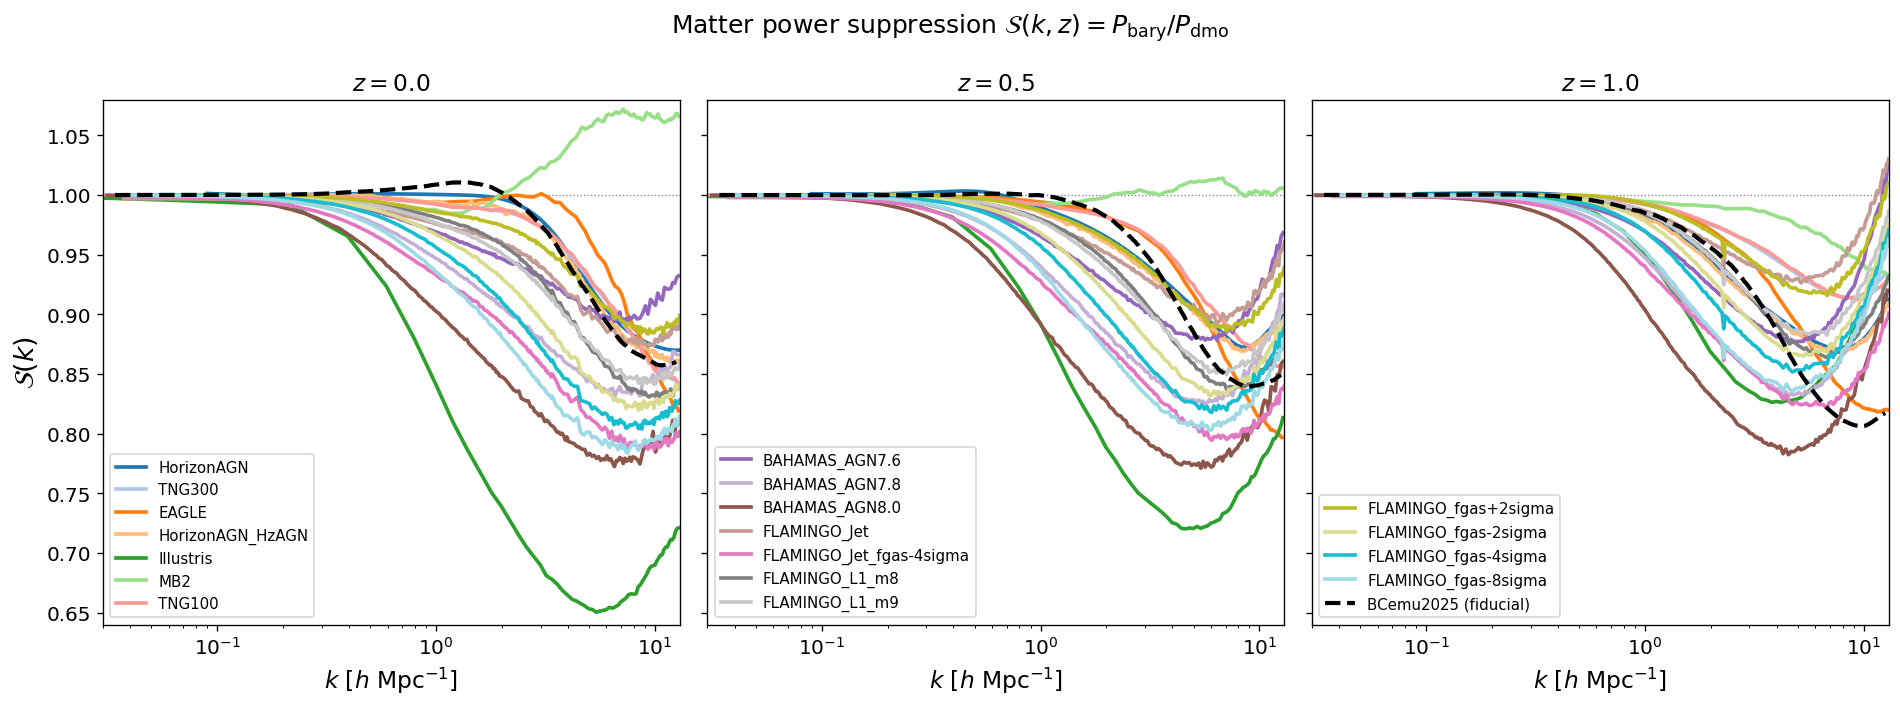

In [5]:
Z_PLOT  = [0.0, 0.5, 1.0]
K_RANGE = (0.03, 13.0)  # h/Mpc

sim_names = list(hydrosims.keys())
colors    = cm.tab20(np.linspace(0, 1, len(sim_names)))
sim_color = dict(zip(sim_names, colors))

fig, axs = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
fig.suptitle(
    r'Matter power suppression $\mathcal{S}(k,z)=P_{\rm bary}/P_{\rm dmo}$',
    fontsize=15
    )

k_emu_full = emu.k
mask_emu   = (k_emu_full >= K_RANGE[0]) & (k_emu_full <= K_RANGE[1])

for ax, z_target in zip(axs, Z_PLOT):
    ax.axhline(1, color='grey', lw=0.8, ls=':')

    # ── Hydrosims ─────────────────────────────────────────────────────
    for name, d in hydrosims.items():
        iz = int(np.argmin(np.abs(d['z'] - z_target)))
        if abs(d['z'][iz] - z_target) > 0.3:
            continue
        mask = (d['k'] >= K_RANGE[0]) & (d['k'] <= K_RANGE[1])
        if mask.sum() < 3:
            continue
        ax.plot(d['k'][mask], d['Sk'][iz, mask],
                color=sim_color[name], lw=2.2, label=name)

    # ── BCemu2025 fiducial ─────────────────────────────────────────────
    _, Sk_emu = emu.get_boost(bcmdict_fid, z=z_target)
    ax.plot(k_emu_full[mask_emu], Sk_emu[mask_emu],
            'k--', lw=2.5, label='BCemu2025 (fiducial)')

    ax.set_xscale('log')
    ax.axis([K_RANGE[0], K_RANGE[1], 0.64, 1.08])
    ax.set_xlabel(r'$k$ [$h$ Mpc$^{-1}$]', fontsize=14)
    ax.set_title(f'$z = {z_target:.1f}$', fontsize=14)

axs[0].set_ylabel(r'$\mathcal{S}(k)$', fontsize=16)

# Distribute labels evenly across the three panel legends
all_handles, all_labels = axs[0].get_legend_handles_labels()
n_total  = len(all_labels)
chunk    = (n_total + 2) // 3  # ceiling division into 3 groups
for ax, start in zip(axs, range(0, n_total, chunk)):
    h = all_handles[start:start + chunk]
    l = all_labels [start:start + chunk]
    ax.legend(h, l, loc='lower left', ncol=1)

plt.tight_layout()
# plt.savefig('hydrosims_suppression_comparison.pdf', bbox_inches='tight')
plt.show()